<a href="https://colab.research.google.com/github/bnatsumi/calculo-numerico/blob/main/CN_Atividade_pr%C3%A1tica_2_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade prática II
## Estabilidade numérica e overflow

Simulação da difusão de velocidade entre duas placas paralelas: a placa em $y = 0$ desliza a
$U = 1$ m/s e a placa em $y = H$ fica parada.

Bruna Natsumi Ideyama

## 1. Verificação da estabilidade

Cálculo de $\Delta y$, $\Delta t_{max}$ e $r$ **antes** de executar a simulação.

In [1]:
import matplotlib.pyplot as plt

MATCHA   = "#42852c"   # casos estaveis
MORANGO  = "#e0407a"   # casos instaveis
LILAS    = "#7150cc"
CARAMELO = "#c98510"
CREME    = "#fffbf9"
AMEIXA   = "#3d2b33"   # texto
MALVA    = "#7a6069"   # texto secundario
LINHA    = "#f0dde0"   # grade

MATCHA_CLARO  = ["#cfe3c2", "#94c07c", MATCHA, "#2b5c1c"]   # rampa (tempo)
MORANGO_CLARO = ["#f6c2d5", "#ec7ba5", MORANGO]             # rampa (passos)

plt.rcParams.update({
    "font.size": 11,
    "figure.facecolor": CREME, "axes.facecolor": CREME,
    "axes.edgecolor": LINHA, "axes.labelcolor": MALVA,
    "xtick.color": MALVA, "ytick.color": MALVA,
    "text.color": AMEIXA, "axes.titlecolor": AMEIXA,
    "axes.grid": True, "grid.color": LINHA, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

CORES = {
    "float64, dt=0.001": MATCHA,    "float32, dt=0.001": LILAS,
    "float64, dt=0.002": MORANGO,   "float32, dt=0.002": CARAMELO,
}
ESTILO = {
    "float64, dt=0.001": "-",  "float32, dt=0.001": (0, (4, 4)),
    "float64, dt=0.002": "-",  "float32, dt=0.002": (0, (4, 4)),
}
print("paleta carregada")

paleta carregada


In [2]:
import numpy as np
import matplotlib.pyplot as plt

H  = 0.01     # distancia entre placas [m]
nu = 1e-4     # viscosidade cinematica [m^2/s]
U  = 1.0      # velocidade da placa movel [m/s]

for pontos in (21, 41):
    dy = H / (pontos - 1)
    dt_max = dy**2 / (2 * nu)
    print(f"{pontos} pontos:  dy = {dy:.5f} m   dt_max = {dt_max:.6f} s")
    for dt in (0.001, 0.002, 0.0002):
        r = nu * dt / dy**2
        status = "ESTAVEL" if r <= 0.5 else "INSTAVEL"
        print(f"     dt = {dt:<8} ->  r = {r:.3f}   {status}")
    print()

21 pontos:  dy = 0.00050 m   dt_max = 0.001250 s
     dt = 0.001    ->  r = 0.400   ESTAVEL
     dt = 0.002    ->  r = 0.800   INSTAVEL
     dt = 0.0002   ->  r = 0.080   ESTAVEL

41 pontos:  dy = 0.00025 m   dt_max = 0.000312 s
     dt = 0.001    ->  r = 1.600   INSTAVEL
     dt = 0.002    ->  r = 3.200   INSTAVEL
     dt = 0.0002   ->  r = 0.320   ESTAVEL



Resultado (21 pontos): $\Delta y = 0{,}0005$ m, $\Delta t_{max} = 0{,}00125$ s.

| Caso | $\Delta t$ | $r$ | Classificação |
|---|---|---|---|
| A | 0,001 s | 0,40 | **Estável** ($r \le 1/2$) |
| B | 0,002 s | 0,80 | **Instável** ($r > 1/2$) |

No caso B o coeficiente central vale $1-2(0{,}8) = -0{,}6$ — negativo.

**2. Detecção de overflow**

Código fornecido pela professora, executado sem alterações. `np.errstate(over="raise")` transforma o aviso de overflow em exceção, interrompendo o cálculo no passo exato da falha.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [4]:
import pandas as pd

linhas = []
for nome, res in resultados.items():
    tipo, dt = nome.split(", dt=")

    passo_nao_fisico = next((i for i, m in enumerate(res["maximos"]) if m > 1 + 1e-9), None)
    linhas.append({
        "tipo": tipo,
        "dt (s)": float(dt),
        "r": round(res["r"], 4),
        "overflow": "sim" if res["falha"] else "nao",
        "passo da falha": res["falha"],
        "1o passo |u|>1": passo_nao_fisico,
        "max |u| final": f'{res["maximos"][-1]:.3e}',
    })

tabela = pd.DataFrame(linhas)
tabela

,tipo,dt (s),r,overflow,passo da falha,1o passo |u|>1,max |u| final
0,float32,0.001,0.4,nao,NaN,NaN,1.000e+00
1,float32,0.002,0.8,sim,121.0,3.0,1.666e+38
2,float64,0.001,0.4,nao,NaN,NaN,1.000e+00
3,float64,0.002,0.8,sim,917.0,3.0,4.743e+307


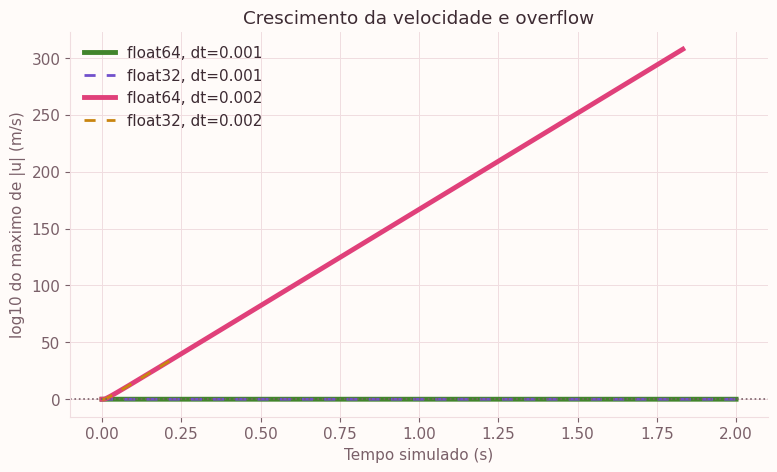

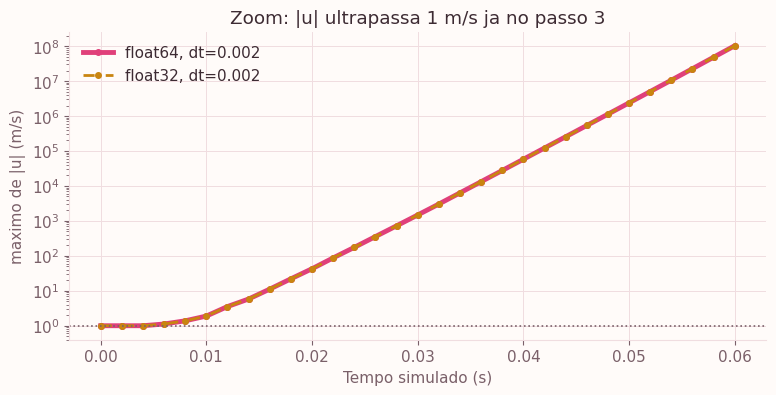

In [5]:
plt.figure(figsize=(9, 5))
ORDEM = ["float64, dt=0.001", "float32, dt=0.001",
         "float64, dt=0.002", "float32, dt=0.002"]
for nome in ORDEM:
    res = resultados[nome]
    plt.plot(res["tempos"], np.log10(np.maximum(res["maximos"], 1e-30)),
             color=CORES[nome], ls=ESTILO[nome], lw=3.5 if "64" in nome else 2, label=nome)
plt.axhline(0, color=MALVA, ls=":", lw=1.2)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("log10 do maximo de |u| (m/s)")
plt.title("Crescimento da velocidade e overflow")
plt.legend()
plt.show()

#  a solucao ja esta errada muito antes do overflow
plt.figure(figsize=(9, 4))
for nome in ("float64, dt=0.002", "float32, dt=0.002"):
    res = resultados[nome]
    plt.semilogy(res["tempos"][:31], res["maximos"][:31], marker="o", ms=4,
                 color=CORES[nome], ls=ESTILO[nome],
                 lw=3.5 if "64" in nome else 2, label=nome)
plt.axhline(1, color=MALVA, ls=":", lw=1.2)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("maximo de |u| (m/s)")
plt.title("Zoom: |u| ultrapassa 1 m/s ja no passo 3")
plt.legend()
plt.show()

**Tabela dos testes (2000 passos, 21 pontos):**

| Tipo | $\Delta t$ (s) | $r$ | Overflow | Passo da falha | Tempo da falha |
|---|---|---|---|---|---|
| float32 | 0,001 | 0,40 | não | — | — |
| float64 | 0,001 | 0,40 | não | — | — |
| float32 | 0,002 | 0,80 | **sim** | 121 | 0,240 s |
| float64 | 0,002 | 0,80 | **sim** | 917 | 1,832 s |

Nos casos estáveis o máximo de $|u|$ permanece exatamente 1,0 m/s (a própria placa móvel).
Nos casos instáveis, $|u|$ ultrapassa 1 m/s já no passo 3, muito antes do overflow.

## 3. Interpretação física

O crescimento que aparece no caso instável não representa um comportamento físico real.

1. Não existe uma fonte de energia para gerar esse crescimento, a única coisa que movimenta o fluido é a placa, que se move a 1 m/s, como não existe gradiente de pressão ou outra força externa atuando no sistema, a velocidade do fluido deveria permanecer entre 0 e 1 m/s, por isso, valores na ordem de $10^{38} m/s$ não fazem sentido fisicamente, já que são muito maiores até mesmo que a velocidade da luz.

2. A viscosidade tende a suavizar o perfil de velocidade, nesse caso, a difusão de quantidade de movimento faz com que as diferenças de velocidade entre os pontos diminuam ao longo do tempo, portanto, o esperado é que o perfil fique cada vez mais suave, e não que as oscilações aumentem.

3. As velocidades negativas também mostram que existe um problema numérico, no resultado instável, aparecem oscilações muito grandes entre pontos vizinhos da malha, fazendo com que a velocidade fique alternando entre valores positivos e negativos. Esse comportamento não tem uma explicação física para o problema considerado.

Isso acontece porque, quando $r > 1/2$, o coeficiente central $(1-2r)$ fica negativo. Com isso, a atualização deixa de funcionar como uma média ponderada dos pontos vizinhos, para o modo mais oscilatório da malha, o fator de amplificação é $|1-4r|$, como $r=0,8$, esse fator é igual a $2,2$, assim, a cada passo a oscilação é multiplicada por 2,2, causando um crescimento exponencial. Depois de 100 passos, por exemplo, temos aproximadamente $2,2^{100} \approx 10^{34}$, o que explica os valores extremamente altos observados na simulação.


dt=0.002, float64: 5 passos sem overflow.
dt=0.002, float64: 15 passos sem overflow.
dt=0.002, float64: 25 passos sem overflow.


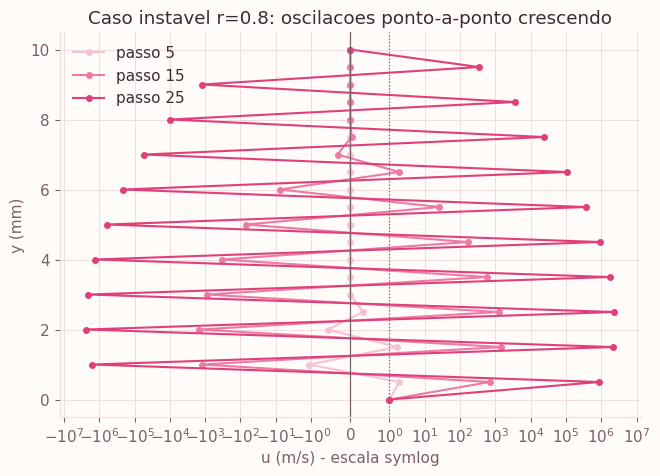

In [6]:
plt.figure(figsize=(7.5, 5))
for passos, cor in zip((5, 15, 25), MORANGO_CLARO):
    rr = simular(0.002, np.float64, passos=passos)
    plt.plot(rr["u"], rr["y"] * 1000, "o-", ms=4, color=cor, label=f"passo {passos}")
plt.xscale("symlog", linthresh=1)
plt.axvline(0, color=MALVA, lw=.9)
plt.axvline(1, color=MALVA, lw=.9, ls=":")
plt.xlabel("u (m/s) - escala symlog")
plt.ylabel("y (mm)")
plt.title("Caso instavel r=0.8: oscilacoes ponto-a-ponto crescendo")
plt.legend()
plt.show()

## 4. Capacidade de representação

Mudar o tipo numérico não resolve a instabilidade, a condicção de estabilidade depende do método utilizado do tamanho da malha e do passo de tempo, o tipo  numérico usado, como `float32`ou `float64`, não altera essa condição, portanto com o \(r =0,8\), os dois tipos apresentam a mesma instabilidade e o mesmo faltor de crescimento a cada passo, a diferença é que o `float64`consegue representar números maiores e com mais precisão, então a simulação demora mais pra atingir valores que causam erro, ou seja ele apenas "atrasa o problema", mas não corrige a instabilidade do método.

Estimativa do número de passos até a falha: como o valor máximo cresce aproximadamente por um fator $g=|1-4r|=2,2$ a cada passo, partindo de um valor próximo de 1 m/s, podemos estimar quantos passos são necessários para atingir um determinado limite $T$ usando:

$$
n \approx \frac{\log_{10}(T)}{\log_{10}(2,2)}
$$

Como $\log_{10}(2,2) \approx 0,342$, fica fácil estimar o número de passos necessários para chegar ao limite de representação do tipo numérico utilizado.


In [7]:
g = abs(1 - 4 * 0.8)          # fator de amplificacao do modo mais oscilatorio
for nome, T in [("float32", np.finfo(np.float32).max),
                ("float64", np.finfo(np.float64).max)]:
    n = np.log10(T) / np.log10(g)
    print(f"{nome}: teto = {T:.3e}, log10(T) = {np.log10(T):.1f}, n previsto = {n:.0f}")

print()
print("Medido:   float32 -> 121 passos | float64 -> 917 passos")
print(f"Razao medida  : 917/121 = {917/121:.2f}")
print(f"Razao dos tetos: {np.log10(np.finfo(np.float64).max)/np.log10(np.finfo(np.float32).max):.2f}")

float32: teto = 3.403e+38, log10(T) = 38.5, n previsto = 113
float64: teto = 1.798e+308, log10(T) = 308.3, n previsto = 900

Medido:   float32 -> 121 passos | float64 -> 917 passos
Razao medida  : 917/121 = 7.58
Razao dos tetos: 8.00


As duas estimativas ficam bem próximas $\(\app\rox 7,6\)$ e \(\approx 8,0\)), isso mostra que o `float64` consegue executar cerca de 8 vezes mais passos antes de atingir o limite de representação e isso acontece principalmente porque o expoente máximo do `float64` é aproximadamente 8 vezes maior que o do `float32`, só que isso não significa que o resultado do `float64`seja melhor, nos dois casos, a solução já deixa de ser útil a partir do passo 3, quando os valores começam a crescer de forma exagerada. Por isso, aumentar a precisão não resolve o problema, usar `float64`apenas faz com que o overflow demorre mais pra acontecer, mas a causa da instabilidade continua sendo a mesma( \(r > 1/2\)). A solução correta é diminuir o tempo de Δ𝚝 de forma que a condição de estabilidade seja respeitada.



## 5. Refinamento da malha

Com **41 pontos**: $\Delta y = 0{,}01/40 = 0{,}00025$ m (metade do anterior).

Como o limite depende de $\Delta y^{2}$:
$\Delta t_{max} = (0{,}00025)^2/(2\times10^{-4}) = 3{,}125\times10^{-4}$ s — **um quarto** do limite anterior.

Mantendo $\Delta t = 0{,}001$ s: $r = 1{,}6$, muito acima de 1/2 (fator de amplificação $|1-4r| = 5{,}4$).
Escolha estável: $\Delta t = 0{,}0002$ s, que dá $r = 0{,}32$.

In [9]:
dy41 = H / 40
print(f"41 pontos: dy = {dy41:.5f} m, dt_max = {dy41**2/(2*nu):.7f} s\n")

ref = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.0002):
        ref[(tipo.__name__, dt)] = simular(dt, tipo, passos=2000, pontos=41)

print()
for (tipo, dt), res in ref.items():
    print(f"41 pontos | {tipo} | dt={dt} | r={res['r']:.3f} | "
          f"falha={res['falha']} | max|u| final={res['maximos'][-1]:.3e}")

41 pontos: dy = 0.00025 m, dt_max = 0.0003125 s

dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dt=0.0002, float32: 2000 passos sem overflow.
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
dt=0.0002, float64: 2000 passos sem overflow.

41 pontos | float32 | dt=0.001 | r=1.600 | falha=56 | max|u| final=7.080e+37
41 pontos | float32 | dt=0.0002 | r=0.320 | falha=None | max|u| final=1.000e+00
41 pontos | float64 | dt=0.001 | r=1.600 | falha=426 | max|u| final=8.872e+307
41 pontos | float64 | dt=0.0002 | r=0.320 | falha=None | max|u| final=1.000e+00


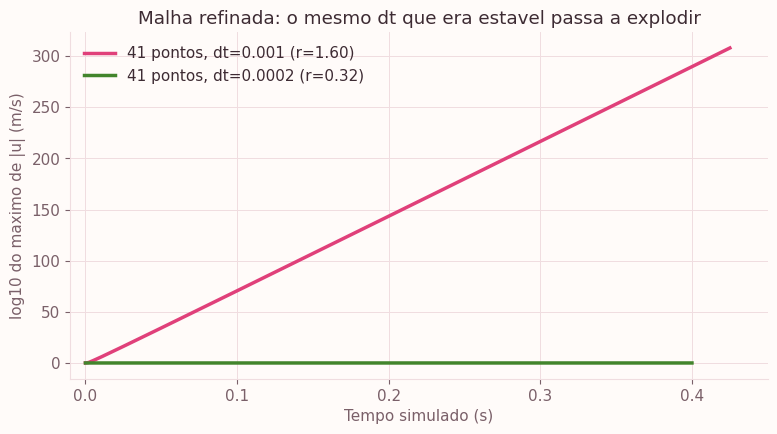

In [10]:
plt.figure(figsize=(9, 4.5))
for dt, cor in ((0.001, MORANGO), (0.0002, MATCHA)):
    res = ref[("float64", dt)]
    plt.plot(res["tempos"], np.log10(np.maximum(res["maximos"], 1e-30)), lw=2.5, color=cor,
             label=f"41 pontos, dt={dt} (r={res['r']:.2f})")
plt.xlim(-0.01, 0.45)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("log10 do maximo de |u| (m/s)")
plt.title("Malha refinada: o mesmo dt que era estavel passa a explodir")
plt.legend()
plt.show()

**Resultados medidos (41 pontos):**

| $\Delta t$ (s) | $r$ | Tipo | Overflow | Passo da falha |
|---|---|---|---|---|
| 0,001 | 1,60 | float32 | sim | 56 |
| 0,001 | 1,60 | float64 | sim | 426 |
| 0,0002 | 0,32 | float32 | não | — |
| 0,0002 | 0,32 | float64 | não | — |


Refinar a malha também aumenta o custo da simulação, em métodos explícitos, ao dobrar o número de pontos da malha, é necessário reduzir $\Delta t$ por um fator de 4 para manter a estabilidade, cm isso, além de termos o dobro de pontos, também precisamos de 4 vezes mais passos de tempo. No total, o custo da simulação aumenta em aproximadamente 8 vezespara representar o mesmo intervalo de tempo físico.




## 6. Verificação do perfil de velocidade

Execução estável e longa: 21 pontos, float64, $\Delta t = 0{,}001$ s, 2000 passos ($t = 2$ s).

Solução estacionária (Couette): $u_{est}(y) = U\left(1 - \dfrac{y}{H}\right)$.

Erro: $E_\infty = \max_i |u_i - u_{est}(y_i)|$.

dt=0.001, float64: 2000 passos sem overflow.

E_inf = 1.605e-09 m/s   em t = 2.0 s
dt=0.001, float64: 50 passos sem overflow.
dt=0.001, float64: 250 passos sem overflow.
dt=0.001, float64: 1000 passos sem overflow.
dt=0.001, float64: 2000 passos sem overflow.


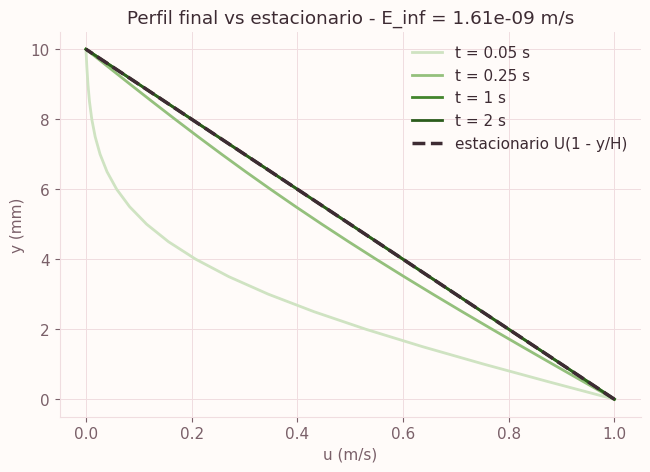

In [11]:
res = simular(0.001, np.float64, passos=2000, pontos=21)
y = res["y"]
u_est = U * (1 - y / H)
E_inf = np.max(np.abs(res["u"] - u_est))
print(f"\nE_inf = {E_inf:.3e} m/s   em t = {2000 * 0.001} s")

plt.figure(figsize=(7.5, 5))
for (passos, lb), cor in zip([(50, "t = 0.05 s"), (250, "t = 0.25 s"),
                              (1000, "t = 1 s"), (2000, "t = 2 s")], MATCHA_CLARO):
    rr = simular(0.001, np.float64, passos=passos, pontos=21)
    plt.plot(rr["u"], rr["y"] * 1000, lw=2, color=cor, label=lb)
plt.plot(u_est, y * 1000, "--", color=AMEIXA, lw=2.5, label="estacionario U(1 - y/H)")
plt.xlabel("u (m/s)")
plt.ylabel("y (mm)")
plt.title(f"Perfil final vs estacionario - E_inf = {E_inf:.2e} m/s")
plt.legend()
plt.show()

In [12]:
# O tempo simulado foi suficiente? Evolucao do erro.
print("   t (s)      E_inf (m/s)")
for t_alvo in (0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0):
    n = int(round(t_alvo / 0.001))
    rr = simular(0.001, np.float64, passos=n, pontos=21)
    print(f"  {t_alvo:>6}    {np.max(np.abs(rr['u'] - u_est)):.3e}")

print(f"\nTempo caracteristico de difusao H^2/nu = {H**2/nu:.2f} s")

   t (s)      E_inf (m/s)
dt=0.001, float64: 50 passos sem overflow.
    0.05    3.938e-01
dt=0.001, float64: 100 passos sem overflow.
     0.1    2.361e-01
dt=0.001, float64: 250 passos sem overflow.
    0.25    5.349e-02
dt=0.001, float64: 500 passos sem overflow.
     0.5    4.504e-03
dt=0.001, float64: 1000 passos sem overflow.
     1.0    3.194e-05
dt=0.001, float64: 2000 passos sem overflow.
     2.0    1.605e-09
dt=0.001, float64: 5000 passos sem overflow.
     5.0    3.442e-15

Tempo caracteristico de difusao H^2/nu = 1.00 s


**Resposta:** $E_\infty = 1{,}61\times10^{-9}$ m/s em $t = 2$ s — cerca de $1{,}6\times10^{-7}\%$ da
velocidade da placa. O perfil numérico e a reta estacionária são indistinguíveis.

| $t$ (s) | $E_\infty$ (m/s) |
|---|---|
| 0,05 | $3{,}94\times10^{-1}$ |
| 0,25 | $5{,}35\times10^{-2}$ |
| 0,50 | $4{,}50\times10^{-3}$ |
| 1,00 | $3{,}19\times10^{-5}$ |
| 2,00 | $1{,}61\times10^{-9}$ |
| 5,00 | $3{,}44\times10^{-15}$ |

**O tempo de simulação foi suficiente?** Sim. O tempo característico de difusão é $H^2/\nu = 1 s$ e, em $t=2$ s, o termo transiente vale aproximadamente:

$$
e^{-19,7} \approx 3 \times 10^{-9}
$$

Esse valor é da mesma ordem do $E_{\infty}$ obtido, portanto, o pequeno erro restante vem do transiente, e não da discretização espacial, como a solução estacionária é uma reta, sua segunda derivada é zero e a diferença central não gera erro de truncamento espacial, com mais tempo de simulação, o $E_{\infty}$ tende ao limite de precisão da máquina.

## 7. Conclusão

No final, a instabilidade pode ser entendida pela relação entre a malha e o passo de tempo.

1. A malha influencia o passo de tempo, quando $\Delta y$ diminui, o valor máximo permitido para $\Delta t$ também diminui, seguindo

$$
\Delta t_{max} = \frac{\Delta y^2}{2\nu}
$$

Assim, se o tamanho da malha é reduzido pela metade, o passo de tempo precisa ser reduzido em quatro vezes.

2. O valor de $r$ depende desses dois valores, quando $\Delta t$ fica maior que o permitido, $r = \nu\Delta t/\Delta y^2$ passa de $1/2$, nesse caso, o coeficiente central $(1-2r)$ fica negativo e o método deixa de se comportar como uma média dos pontos vizinhos.

3. Isso faz a solução ficar instável, as oscilações entre os pontos começam a aumentar a cada passo, para $(r>1/2)$, o fator de amplificação é $|1-4r|$, no nosso caso, a solução já começa a apresentar valores sem sentido a partir do passo 3.

4. Depois aparece o overflow, como os valores continuam crescendo, eles acabam ultrapassando o limite que o tipo numérico consegue representar. Isso acontece em torno de $10^{38}$para `float32` e $10^{308}$ para `float64`, portanto, o overflow é uma consequência do problema, e não a causa da instabilidade.

Para corrigir a simulação, foi necessário diminuir $\Delta t$ e respeitar a condição

$$
\Delta t \leq \frac{\Delta y^2}{2\nu}
$$

Na malha de 21 pontos, usamos $\Delta t=0{,}001\ s$, com $(r=0{,}4)$. Já na malha de 41 pontos, usamos $\Delta t=0{,}0002$ s, com $r=0{,}32$. Com esses valores, o máximo de $|u|$ continua em 1 m/s e o resultado converge para a solução exata, chegando a $E_{\infty}\approx10^{-9} m/s$.

Trocar `float32` por `float64` não resolveu a instabilidade. O que mudou foi apenas o número de passos antes do overflow, que passou de 121 para 917. Como o problema já aparecia no passo 3, aumentar a precisão só fez o overflow acontecer mais tarde.

> Resumindo um pouco, o problema estava no passo de tempo usado pelo método. Diminuir $\Delta t$ corrige a instabilidade, enquanto trocar o tipo numérico apenas aumenta o tempo até o overflow.
